# Option market-making and vol arbitrage 

`src/option_market_making` implements the baseline single-option model of
**Lucic & Tse (2025)**, *"Option market-making and vol arbitrage"* (Risk.net).

In [70]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import json, warnings
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from option_market_making import bs_mm, riccati
from option_market_making.edge import phi_edge
from option_market_making.psi1 import flow_corrections, psi1
from option_market_making.quoting import MMParams, optimal_spreads
from option_market_making.pde import solve_hjb_pde
from option_market_making.sim import objective, objective_summary, simulate

%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#dcdcd8'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
    'axes.titlecolor': INK, 'axes.titlesize': 11, 'axes.titleweight': 'semibold',
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'lines.linewidth': 2.0,
})

## 1. The surface and the contract

The market-implied vol comes from the calibrated **Global eSSVI** surface in `vol_surface`, it rebuilds a GlobalESSVISurface object from a frozen JSON file.
This notebook replays the frozen Deribit snapshot the test-suite uses, so every number below is
reproducible; flip `USE_LIVE = True` to recalibrate against the live chain instead.

In [71]:
USE_LIVE = False   # True re-pulls Deribit and recalibrates (needs network)

from vol_surface.global_essvi import ESSVISlice, GlobalESSVISurface

SNAPSHOT = '../tests/option_market_making/deribit_snapshot.json'

if USE_LIVE:
    from vol_surface import global_essvi as ge
    chain = ge.fetch_quotes(currency='BTC', max_T=1.5)
    surface = ge.calibrate(**ge.chain_to_calibration_inputs(chain)).surface
    tau = min(surface.maturities, key=lambda t: abs(t - 30 / 365))
    S0 = float(surface.forward_at(tau))
    K = round(S0, -3)
else:
    snap = json.load(open(SNAPSHOT))
    surface = GlobalESSVISurface(
        snap['maturities'], [ESSVISlice(**s) for s in snap['slices']], snap['forwards'],
    )
    S0, K, tau = snap['spot'], snap['strike'], snap['tau']

IV = bs_mm.sigma_imp(surface, K, tau)
O_0 = bs_mm.call_price(S0, K, tau, IV)

print(f"spot        S0    = {S0:,.0f}")
print(f"strike      K     = {K:,.0f}   ({K / S0 - 1:+.2%} moneyness)")
print(f"expiry      tau   = {tau:.4f} yr  ({tau * 365:.0f} calendar days)")
print(f"implied vol       = {IV:.2%}")
print(f"call mark   O(0)  = {O_0:,.0f}   ({O_0 / S0:.2%} of spot)")

spot        S0    = 79,420
strike      K     = 80,000   (+0.73% moneyness)
expiry      tau   = 0.0847 yr  (31 calendar days)
implied vol       = 40.75%
call mark   O(0)  = 3,485   (4.39% of spot)


## 2. Parameters

Maker's view of volatility $\sigma$, the arrival
intensities $\lambda_0^i$ and the decays $\kappa^i$ for $i\in \{a,b\}$ are inputs. 

| Parameter | Value |
| --- | --- |
| $1/\kappa^b,\ 1/\kappa^a$ | $40, $33 |
| $\lambda_0^b,\ \lambda_0^a$ | 100/day/side, bid 15% heavier |
| $\alpha,\ \beta$ | 2, 4357 |
| $\sigma$ | implied vol + 5 vol pts |
| $T$ | 0.5/252 |

Given maturity $\tau$ and strike price $K$, the maker thinks realised will beat implied — they want to be **long** vol, with half a trading day $T$. 
Market-making takes place over a time interval $[0,T]$, with $T\in (0,\tau).$

The optimal bid/ask half-spreads (eq. 11) are:

$$\delta^{b,*}(t,s,q) = \underbrace{\frac{1}{\kappa^b}}_{\text{liquidity}} \;-\; \underbrace{\psi_1(t,s)}_{\text{vol-arb edge + order-flow}} \;-\; \underbrace{(2q+1)\,\psi_2(t)}_{\text{inventory control}}$$

$$\delta^{a,*}(t,s,q) = \underbrace{\frac{1}{\kappa^a}}_{\text{liquidity}} \;+\; \underbrace{\psi_1(t,s)}_{\text{vol-arb edge + order-flow}} \;+\; \underbrace{(2q-1)\,\psi_2(t)}_{\text{inventory control}}$$

with $\kappa^b,\kappa^a$ the bid/ask intensity decays, and $q$ the market
maker's current inventory in holdings ($q>0$ = long the option, $q<0$ = short).

$\psi_1(t,s)$ splits into eq. 9's three terms — the vol-arb edge, plus two **order-flow
correction** terms that exist only because the bid and ask sides of the book are not symmetric:

$$\psi_1(t,s) = \underbrace{\varphi(t,s)}_{\text{vol-arb edge}} \;+\; \underbrace{2e^{-1}\,(\lambda_0^b - \lambda_0^a) \int_t^T D(t,u)\,\psi_2(u)\,du}_{\text{order-flow correction, linear}} \;+\; \underbrace{2e^{-1}\,(\lambda_0^b\kappa^b - \lambda_0^a\kappa^a) \int_t^T D(t,u)\,\psi_2(u)^2\,du}_{\text{order-flow correction, quadratic}}$$

where
$\lambda_0^b - \lambda_0^a$ and $\lambda_0^b\kappa^b - \lambda_0^a\kappa^a$
are the bid/ask imbalance in base fill intensity and in fill elasticity. Note that both are zero for a
symmetric book ($\lambda_0^b=\lambda_0^a,\ \kappa^b=\kappa^a$), in which case the order-flow
correction vanishes and $\psi_1 = \varphi$.

$D(t,u)$ and $\psi_2(u)$ are section §3's objects; the edge term $\varphi(t,s)$ (eq. 10) is

$$\varphi(t,s) = \frac{K(\sigma^2-\sigma_{\text{imp}}^2)}{2} \int_t^T \frac{D(t,u)}{\sqrt{\sigma_{\text{imp}}^2(\tau-u)+\sigma^2(u-t)}}\, \phi\bigg(\frac{\ln(s/K) - \tfrac12\sigma^2(u-t) - \tfrac12\sigma_{\text{imp}}^2(\tau-u)}{\sqrt{\sigma_{\text{imp}}^2(\tau-u)+\sigma^2(u-t)}} \bigg)\, du,
$$

with $\phi(\cdot)$ the standard normal density, $\sigma$ the market maker's own vol view, and
$\sigma_{\text{imp}}$ the market's implied vol. **Only $\varphi$ carries spot price dependence** — the order-flow
correction is a function of $t$ alone, never of $s$, $K$, or $\tau$.

The code cell below evaluates every term at $t=0,\ s=S_0,\ q=0$.

In [72]:
PARAMS = MMParams(
    alpha=2.0, beta=4357.0,
    lambda0_b=252 * 100 * 1.15, lambda0_a=252 * 100.0,
    kappa_b=0.025, kappa_a=0.030,
    sigma=IV + 0.05,
)
T = 0.5 / 252

Q0 = 0.0   # inventory level this decomposition is evaluated at

edge_0 = phi_edge(0.0, S0, K, tau, T, IV, PARAMS)
flow_0 = flow_corrections(0.0, T, PARAMS)
psi2_0 = riccati.psi2(0.0, T, PARAMS)
db_0, da_0 = optimal_spreads(0.0, S0, Q0, K, tau, T, IV, PARAMS)

anatomy = pd.DataFrame({
    'component':    ['liquidity', 'vol-arb edge', 'order-flow correction', 'inventory', 'TOTAL half-spread'],
    'bid formula':  ['1/\u03ba\u1d47', '\u2212\u03c6(t,s)', '\u2212[\u03c8\u2081\u2212\u03c6]',
                     '\u2212(2q+1)\u03c8\u2082(t)', '\u03b4\u1d47,*(t,s,q)'],
    'bid ($)':      [1 / PARAMS.kappa_b, -edge_0, -flow_0, -(2 * Q0 + 1) * psi2_0, db_0],
    'ask formula':  ['1/\u03ba\u1d43', '+\u03c6(t,s)', '+[\u03c8\u2081\u2212\u03c6]',
                     '+(2q\u22121)\u03c8\u2082(t)', '\u03b4\u1d43,*(t,s,q)'],
    'ask ($)':      [1 / PARAMS.kappa_a, edge_0, flow_0, (2 * Q0 - 1) * psi2_0, da_0],
})
anatomy['share of bid'] = (anatomy['bid ($)'].abs() / db_0).map('{:.1%}'.format)
display(anatomy)
print(f"\nquoted width = {db_0 + da_0:,.2f}  ({(db_0 + da_0) / O_0 * 1e4:.0f} bp of the option mark)")


,component,bid formula,bid ($),ask formula,ask ($),share of bid
0,liquidity,1/κᵇ,40.000,1/κᵃ,33.333,95.4%
1,vol-arb edge,"−φ(t,s)",-2.616,"+φ(t,s)",2.616,6.2%
2,order-flow correction,−[ψ₁−φ],2.561,+[ψ₁−φ],-2.561,6.1%
3,inventory,−(2q+1)ψ₂(t),2.000,+(2q−1)ψ₂(t),2.000,4.8%
4,TOTAL half-spread,"δᵇ,*(t,s,q)",41.946,"δᵃ,*(t,s,q)",35.388,100.0%



quoted width = 77.33  (222 bp of the option mark)


**Comment 1:** At a 5-vol-point view the vol-arb edge is $\varphi = +\$2.62$, **6.2% of the bid spread** —
and the order-flow correction comes in at $-\$2.56$, so the two nearly cancels out:
$\psi_1 = \varphi + \text{flow} = +\$0.05$. The vol-arbitrage term $\psi_1$ contributes almost nothing at these parameters. The liquidity term $1/\kappa^b$ accounts for most of the bid spread at 95.4%.

## 3. The inventory weight $\psi_2$ and the discount kernel $D(t,u)$

§2's optimal spreads (eq. 11), recalled here:

$$\delta^{b,*}(t,s,q) = \frac{1}{\kappa^b} - \psi_1(t,s) - (2q+1)\,\psi_2(t)
\qquad
\delta^{a,*}(t,s,q) = \frac{1}{\kappa^a} + \psi_1(t,s) + (2q-1)\,\psi_2(t)$$
The inventory weight $\psi_2(t) <0$ always, accounts for:
$$\psi_2(t) = \sqrt{\varUpsilon\beta}\frac{\zeta_- e^{-\eta(T-t)} - \zeta_+ e^{\eta(T-t)}}{\zeta_- e^{-\eta(T-t)} + \zeta_+ e^{\eta(T-t)}} $$
where
$$\varUpsilon := \frac{1}{2e^{-1}(\lambda_0^{\mathrm{a}}\kappa^{\mathrm{a}} + \lambda_0^{\mathrm{b}}\kappa^{\mathrm{b}})}, \quad \eta := \sqrt{\frac{\beta}{\varUpsilon}}, \quad \zeta_{\pm} := \sqrt{\varUpsilon\beta} \pm \alpha
$$

$\psi_2(t)$ is the coefficient multiplying the inventory adjustment $(2q\pm1)$ on each side.It depends only on $\alpha,\beta$ and the
flow parameters $\lambda_0,\kappa$: never on the spot $s$, strike $K$, or maturity $\tau$.

The discount term:
$$D(t, u) := \frac{\zeta_- e^{-\eta(T-u)} + \zeta_+ e^{\eta(T-u)}}{\zeta_- e^{-\eta(T-t)} + \zeta_+ e^{\eta(T-t)}}$$

$D(t,u)$ discounts edge earned at a future time $u$ back to $t$ *inside*
$\psi_1$'s construction — but its decay rate is exactly what caps how far ahead $\psi_1$ edge term can
exploit (see §4). Both are shown across three values of $\beta$, because at the baseline $\psi_2$ alone is a flat
line.

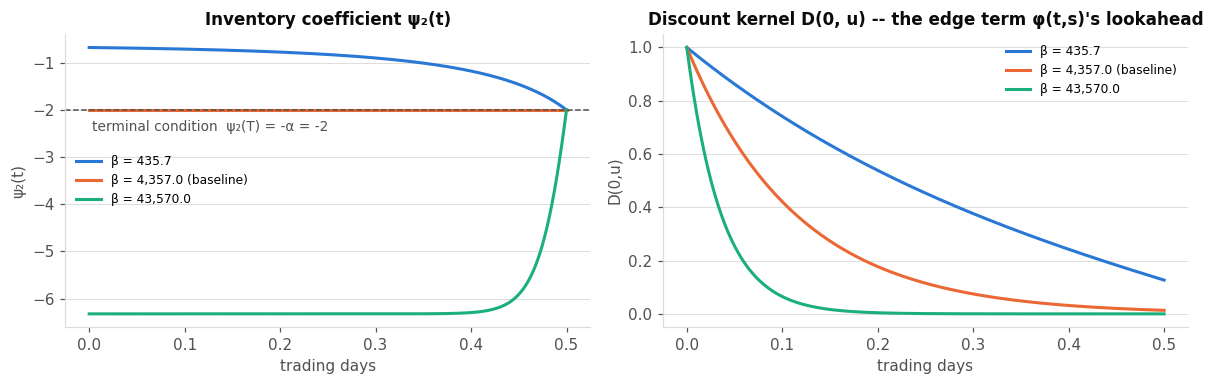

,β,√(Υβ),"D(0, T)"
0,435.700,0.632,0.127
1,"4,357.000",2.000,0.013
2,"43,570.000",6.324,0.000


In [87]:
t_grid = np.linspace(0.0, T, 200)
ups = riccati.upsilon(PARAMS.lambda0_b, PARAMS.kappa_b, PARAMS.lambda0_a, PARAMS.kappa_a)

# Both panels are shown across beta. At the baseline alone psi2 is a flat line 
betas = [435.7, PARAMS.beta, 43570.0]
labels = [f'β = {b:,.1f}' + (' (baseline)' if b == PARAMS.beta else '') for b in betas]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for color, b, label in zip(SERIES, betas, labels):
    p_b = replace(PARAMS, beta=b)
    axes[0].plot(t_grid * 252, [riccati.psi2(float(t), T, p_b) for t in t_grid],
                 color=color, label=label)
    axes[1].plot(t_grid * 252, [riccati.discount_kernel(0.0, float(u), T, p_b) for u in t_grid],
                 color=color, label=label)

axes[0].axhline(-PARAMS.alpha, color=MUTED, lw=1, ls='--')
axes[0].annotate(f'terminal condition  \u03c8\u2082(T) = -α = {-PARAMS.alpha:g}',
                 xy=(0, -PARAMS.alpha), xytext=(2, -14), textcoords='offset points',
                 color=MUTED, fontsize=9)
axes[0].set_title('Inventory coefficient \u03c8\u2082(t)')
axes[0].set_xlabel('trading days'); axes[0].set_ylabel('\u03c8\u2082(t)')

axes[1].set_title('Discount kernel D(0, u) -- the edge term \u03c6(t,s)\'s lookahead')
axes[1].set_xlabel('trading days'); axes[1].set_ylabel('D(0,u)')

for ax in axes:
    ax.legend(fontsize=8); ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

lookahead = pd.DataFrame([
    {'β': b,
     '√(Υβ)': np.sqrt(ups * b),
     'D(0, T)': riccati.discount_kernel(0.0, T, T, replace(PARAMS, beta=b))}
    for b in (435.7, 4357.0, 43570.0)
])

display(lookahead)

$\psi_2(t)$ is how hard we lean on our quote for every unit of inventory we're
carrying. It shows up in the spread as $(2q\pm1)\psi_2(t)$ — the bigger $|\psi_2(t)|$ is, the harder
we react to carrying a position.

It comes from one ODE equation, which is solved backward, not forward:

$$\psi_2'(t) + \frac{\psi_2(t)^2}{\Upsilon} = \beta, \qquad \psi_2(T) = -\alpha$$

The second part says whatever $\beta$ is, $\psi_2$ **must** equal exactly $-\alpha$
at the close of trading ($t=T$). The equilibrium of this backward ODE is solved to be $-\sqrt{\Upsilon\beta}$.

Comparing $-\sqrt{\Upsilon\beta}$ to $-\alpha$ tells:

- **Equal:** $-\sqrt{\Upsilon\beta} = -\alpha$ (true for $\beta=4357$, since $\sqrt{\Upsilon\cdot4357}=2=\alpha$).
  The target and the fixed end-of-day value are the same: $\psi_2(t) = -\alpha \forall t\in[0,T]$. That's the flat orange line.
- **Bigger $\beta$**: $\sqrt{\Upsilon\beta} > \alpha \iff -\sqrt{\Upsilon\beta} < -\alpha$. That's the
  green line ($\beta=43{,}570$).
- **Smaller $\beta$**: $\sqrt{\Upsilon\beta} < \alpha\iff -\sqrt{\Upsilon\beta} > -\alpha$. That's
  the blue line ($\beta=436.7$).

**In every case the trajectory is**: start near the equilibrium $-\sqrt{\Upsilon\beta}$, end at the terminal condition $-\alpha$. The ODE is solved backward (terminal condition is the boundary), but the trading day runs forward.
So: small $\beta$ → curve goes **down**;
big $\beta$ → curve goes **up**; the exactly-matched $\beta$ → flat. 

**Practically**: in the first case ($\zeta_- > 0$, large $\beta$), the model gets aggressive about managing inventory early in the day and relaxes toward the close. In the second case ($\zeta_- < 0$, small $\beta$), it's relaxed early and tightens up as the close approaches. At the constant-edge ($\zeta_- = 0$), it doesn't change at all — constant reaction throughout.

---

$D(t,u)$ answers: *a dollar of profit at some future moment $u$ — how much
is that worth right now, at time $t$?* It equals $1$ at $u=t$ (a dollar today is worth a dollar
today) and shrinks the further away $u$ is — future money gets discounted.

How fast it shrinks is set by $\eta= \sqrt{\beta/\Upsilon}$. When $\zeta_- \neq 0$, for $u$ far enough before $T$ (specifically, $\eta(T-u)$ large), the $\zeta_+ e^{\eta(T-u)}$ term dominates $\zeta_- e^{-\eta(T-u)}$ in the numerator (because the growing exponential overwhelms the decaying one), and similarly in the denominator. So the $\zeta_-$ terms become negligible, and we recover an approximation.

$$D(t,u) \approx e^{-\eta(u-t)}$$

When $\zeta_- = 0$, we have equality. $\eta$ is how fast $D(t,u) $ falls off, measured in 
$e$-foldings per year. Larger $\eta$ means faster rate.

Bigger $\eta$ means faster decrease rate, means a shorter span for future profit. On the right-hand
chart, the green line (same big-$\beta$ case) goes to near zero almost immediately. The blue line (small $\beta$) fades much more slowly, still caring about
profit half a day out.


The **$e$-folding time** ($1/\eta$) is simply the amount of future time it takes for a signal's importance to drop to about $36.8\%$ of its original value.
If we look into the future by setting $u - t = 1/\eta$, the math simplifies:

$$D(t, u) = e^{-\eta\left(\frac{1}{\eta}\right)} = e^{-1} \approx 0.368$$


Because the decay is exponential, multiplying $1/\eta$ dramatically suppresses future information:

* **At $u - t = 1/\eta$:** $D(t,u) = e^{-1} \approx 0.368$ (36.8% influence remains)
* **At $u - t = 3/\eta$:** $D(t,u) = e^{-3} \approx 0.050$ (5% influence remains)
* **At $u - t = 5/\eta$:** $D(t,u) = e^{-5} \approx 0.007$ (less than 1% influence remains)

Therefore, in a general integral like:

$$\int_t^T D(t, u) (\dots) \, du \approx \int_t^{O(1/\eta)} D(t, u) (\dots) \, du $$

the factor $D(t, u)$ acts like a diminishing term for $1/\eta \ll (T-t)$. By the time $u - t$ reaches $3/\eta$, over $95\%$ of the weight is gone. By $5/\eta$, over $99\%$ is gone.

**Because anything beyond $u - t = 3/\eta$ is multiplied by near-zero numbers, events past that point have virtually no impact on the calculation at time $t$. We can safely ignore the rest of the timeline up to $T$.**


---

**The running inventory penalty $\beta$ serves a dual purpose in the model. Beyond its direct role in penalizing variance $\int_0^T Q_u^2 \, du$, $\beta$ caps the lookahead horizon of the volatility-arbitrage edge term $\varphi(t, s)$.**

Increase $\beta$ (we hate inventory more) $\Rightarrow \eta= \sqrt{\beta/\Upsilon}$ increases $\Rightarrow 1/\eta$ decreases $\Rightarrow D(t,u)$ decays faster $\Rightarrow \varphi(t,s)$ only integrates vol-arb profit over a shorter future window $\Rightarrow$ the edge term that shifts our quotes is smaller, because it's discounting away profit we could have harvested over a longer horizon.

Decrease $\beta$ (we're relaxed about inventory) $\Rightarrow \eta= \sqrt{\beta/\Upsilon}$  decreases $\Rightarrow 1/\eta$ increases $\Rightarrow D(t,u)$ decays slower $\Rightarrow \varphi(t,s)$ looks further ahead $\Rightarrow$ bigger edge term, because we're valuing profit we'll collect over a longer window.

## 4. When does the maker's vol view actually move the quote?

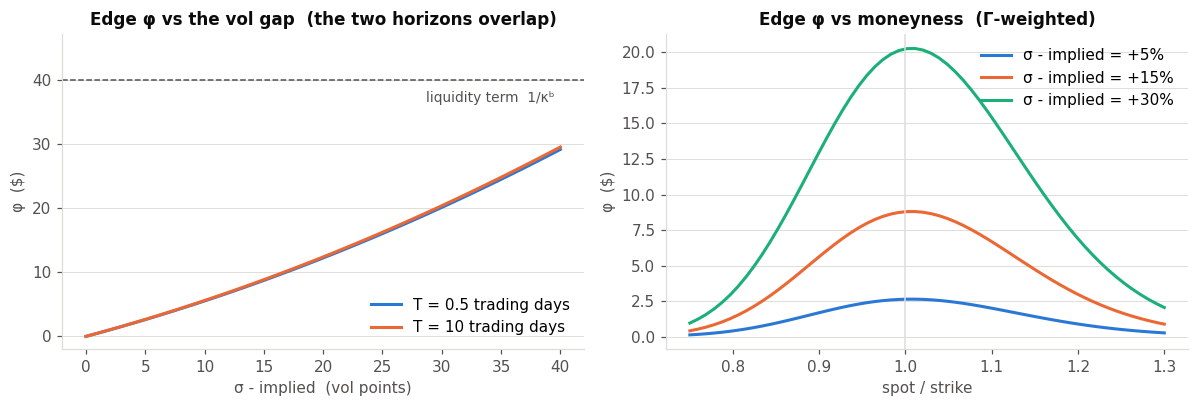

,σ - implied (vol pts),φ ($),as % of 1/κᵇ
0,5,2.616,7%
1,10,5.529,14%
2,20,12.247,31%
3,30,20.140,50%
4,40,29.196,73%


In [74]:
gaps = np.linspace(0.0, 0.40, 40)
horizons_d = [0.5, 10.0]
edge_by_gap = {
    f'T = {d:g} trading days': np.array([
        phi_edge(0.0, S0, K, tau, d / 252, IV, replace(PARAMS, sigma=IV + g)) for g in gaps
    ]) for d in horizons_d
}

moneyness = np.linspace(0.75, 1.30, 60)
edge_by_spot = {
    f'σ - implied = {g:+.0%}': np.array([
        phi_edge(0.0, float(K * m), K, tau, T, IV, replace(PARAMS, sigma=IV + g)) for m in moneyness
    ]) for g in (0.05, 0.15, 0.30)
}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for color, (label, values) in zip(SERIES, edge_by_gap.items()):
    axes[0].plot(gaps * 100, values, color=color, label=label)
axes[0].axhline(1 / PARAMS.kappa_b, color=MUTED, lw=1, ls='--')
axes[0].annotate('liquidity term  1/κᵇ', xy=(gaps[-1] * 100, 1 / PARAMS.kappa_b),
                 xytext=(-4, -14), textcoords='offset points', ha='right',
                 color=MUTED, fontsize=9)
axes[0].set_ylim(top=1 / PARAMS.kappa_b * 1.18)
axes[0].set_title('Edge φ vs the vol gap  (the two horizons overlap)')
axes[0].set_xlabel('σ - implied  (vol points)'); axes[0].set_ylabel('φ  ($)')
axes[0].legend(loc='lower right')   # keeps the legend off the 1/κᵇ reference line

for color, (label, values) in zip(SERIES, edge_by_spot.items()):
    axes[1].plot(moneyness, values, color=color, label=label)
axes[1].axvline(1.0, color=GRID, lw=1)
axes[1].set_title('Edge φ vs moneyness  (Γ-weighted)')
axes[1].set_xlabel('spot / strike'); axes[1].set_ylabel('φ  ($)')
axes[1].legend(loc='upper right')

for ax in axes:
    ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    'σ - implied (vol pts)': [5, 10, 20, 30, 40],
    'φ ($)': [phi_edge(0.0, S0, K, tau, T, IV, replace(PARAMS, sigma=IV + g / 100))
              for g in (5, 10, 20, 30, 40)],
}).assign(**{'as % of 1/κᵇ': lambda d: (d['φ ($)'] / (1 / PARAMS.kappa_b)).map('{:.0%}'.format)}))

**Left chart — $\varphi$ vs. how wrong we think the market is.** The x-axis is our guess minus the
market's implied vol, in vol points; the y-axis is the vol-arb edge, $\varphi$. It goes up: the more
we disagree, the more we can make.

 The two colored lines are a
half-day trading window and a 10-day one, and **they sit almost on top of each other**. This is §3's lookahead result again: the model only "looks ahead" about the interval $[t,t+O(1/\eta)]$ before
it stops caring, so a 10-day window buys nothing extra over a half-day one.

The dashed line at the top ($40) is $1/\kappa^b$ — the plain liquidity charge, with no vol opinion at
all. The curve stays well below it even at a 40-point disagreement.

It means our opinion about volatility barely matters to the price we quote — the price is set almost entirely by other stuff, no matter how right we think we are.
Even our most aggressive volatility opinion never gets to add more than our ordinary liquidity charge does by default. **Our quote is always dominated by "how risky is it to quote a price" not by "how right do I think I am about volatility."**

---

**Right chart — $\varphi$ vs. spot price (moneyness).** All three curves peak right ATM and fall away on
both sides. Because the edge only exists because we are delta-hedging, and how much we have to keep
re-adjusting that hedge as price changes is gamma. **The edge is largest exactly ATM and fades toward zero for options deep ITM or OTM.** So even a strong vol opinion is
close to worthless on an option far from the money.

## 5. The inventory skew

Fact 1: The slope in `q` is exactly `2ψ₂`


$$\delta^{b,*} = \frac{1}{\kappa^b} - \psi_1(t,s) - (2q+1)\psi_2(t) = \underbrace{\Big[\tfrac{1}{\kappa^b}-\psi_1(t,s) -\psi_2(t) \Big]}_{\text{constant in }q} \;-\; 2\psi_2(t)\cdot q$$

which is eq. 11. Written as a function of `q` alone, everything except `q` is a constant. 
**The slope in `q` is `−2ψ₂(t)` — for any `α, β, λ, κ`, at any `t`.** Do the same for the ask side (using `q-1` instead of `q+1`) and we get slope `+2ψ₂(t)`.

Fact 2: The total width

Add the two optimal bid/ask:

$$\delta^{b,*}+\delta^{a,*} = \Big(\tfrac{1}{\kappa^b}-\psi_1(t,s)-(2q+1)\psi_2(t)\Big) + \Big(\tfrac{1}{\kappa^a}+\psi_1(t,s)+(2q-1)\psi_2(t)\Big)= \frac{1}{\kappa^b}+\frac{1}{\kappa^a} - 2\psi_2(t)$$

**General formula, holds for any parameters.** 


This formula says the width is constant in `q`. But it still has a `t` sitting in it, through `ψ₂(t)`. At *our* baseline, `ψ₂(t) ≡ −2` for every `t`, so the width is $77.33 the whole trading day, not just at every `q`.

**Away from the baseline,** if `ψ₂(t)` varies rather than being a constant, the width would still be flat across `q` at any given instant, but it would drift over the course of the day.

In [88]:
q_grid = np.arange(-10, 11)
spreads = np.array([optimal_spreads(0.0, S0, float(q), K, tau, T, IV, PARAMS) for q in q_grid])

display(pd.DataFrame({
    'q': q_grid[::5], 'delta_b* ($)': spreads[::5, 0], 'delta_a* ($)': spreads[::5, 1], 'total width ($)': spreads[::5, 0] + spreads[::5, 1],
    'skew b-a ($)': spreads[::5, 0] - spreads[::5, 1],
}))

,q,delta_b* ($),delta_a* ($),total width ($),skew b-a ($)
0,-10,1.946,75.387,77.333,-73.440
1,-5,21.946,55.387,77.333,-33.441
2,0,41.946,35.388,77.333,6.558
3,5,61.945,15.388,77.333,46.557
4,10,81.945,-4.612,77.333,86.557


**1. The two sides move in opposite directions.** As we get more long ($q$ rising), our
bid keeps climbing (we are less willing to buy) while our
ask keeps falling (we are more willing to sell). The model is
actively trying to get rid of a position it does not want: make it cheap for people to buy from us,
expensive for people to sell to us. 

**2. At $q=+10$ the ask goes negative** ($-\$4.61$): the model would sell the option for *less* than
its theoretical fair value. Saying it would rather take a small guaranteed loss right now than
keep carrying this position — 
because holding the inventory is worse than eating the loss.

## 6. Benchmarks against a fixed-width quoter

Benchmarks against makers who quote a fixed width regardless of state, so both run through on **identical spot paths**. 

The scoring rule matters here. Eq. 11 does not maximise mean $V_T$; it maximises the paper's
objective (eq. 2)

$$\mathbb{E}\Big[\,V_T \;-\; \beta\!\int_0^T Q_u^2\,du \;-\; \alpha\,Q_T^2\,\Big]$$

**Test:** Benchmark the smart rule (eq. 11)
 against fixed-width quoters that never think about inventory or the vol view —
they just pick one fixed width and quote it all day. Three cases: half the plain liquidity width
($\times0.5$, tighter), the plain liquidity width with no adjustment ($\times1$), and double
($\times2$, wider).

Every strategy runs on the **exact same** simulated sequence of price moves — 
only the quoting rule differs. 

The bid-distance and ask-distance to theo are two plain numbers, unchanged into every step of the simulation —  never look at `t`, inventory `q`, or the spot `s`.

"fixed" means the *distance* from the mark is fixed, not the actual dollar price. The mark itself (the option's fair value) moves all day as the spot price moves, so the quoted bid/ask prices *do* move — they're just always sitting exactly `1/κᵇ` below and `1/κᵃ` above wherever the mark currently is, with zero adjustment for anything else. The `×1` case is exactly "quote what the optimal rule *would* quote if we deleted the vol-view term and pretended inventory was always zero" and never updated again.

In [4]:
N_PATHS, N_STEPS = 4000, 400
SIM = dict(S0=S0, n_steps=N_STEPS, n_paths=N_PATHS, seed=1)

runs = {'optimal (eq. 11)': simulate(surface, K, tau, T, PARAMS, **SIM)}
for w in (0.5, 1.0, 2.0):
    runs[f'fixed-width x{w:g}'] = simulate(
        surface, K, tau, T, PARAMS,
        constant_spreads=(w / PARAMS.kappa_b, w / PARAMS.kappa_a), **SIM,
    )

summary = pd.DataFrame([
    {'strategy': name,
     'mean V_T': r.terminal_value.mean(),
     'sd V_T': r.terminal_value.std(),
     'mean / sd': r.terminal_value.mean() / r.terminal_value.std(),
     'fills / path': (r.n_bid_fills + r.n_ask_fills).mean(),
     'sd of q_T': r.q[:, -1].std(),
     'max |q|': np.abs(r.q).max()}
    for name, r in runs.items()
])
display(summary)

,strategy,mean V_T,sd V_T,mean / sd,fills / path,sd of q_T,max |q|
0,optimal (eq. 11),"1,431.351",346.917,4.126,38.397,2.128,10.000
1,fixed-width x0.5,"1,228.900",368.823,3.332,65.273,7.814,39.000
2,fixed-width x1,"1,471.800",361.483,4.072,39.438,6.334,27.000
3,fixed-width x2,"1,081.136",328.458,3.292,14.588,3.803,16.000


In [5]:
assert all(np.array_equal(runs['optimal (eq. 11)'].S, r.S) for r in runs.values()), \
    'paired comparison requires identical spot paths'

print('Eq. 2 -- the quantity eq. 11 actually maximises:')
display(objective_summary(runs, PARAMS))

base = objective(runs['optimal (eq. 11)'], PARAMS)
paired = pd.DataFrame([
    {'vs': name,
     'objective gap': (d := base - objective(r, PARAMS)).mean(),
     '95% CI': 1.96 * d.std() / np.sqrt(N_PATHS),
     't-stat': d.mean() / (d.std() / np.sqrt(N_PATHS)),
     'optimal wins on': f'{100 * (d > 0).mean():.1f}% of paths'}
    for name, r in runs.items() if not name.startswith('optimal')
])
display(paired)

Eq. 2 -- the quantity eq. 11 actually maximises:


,strategy,mean V_T,running penalty/fee,terminal penalty/fee,OBJECTIVE (value after fees),objective sd
0,optimal (eq. 11),"1,431.351",37.269,9.969,"1,384.114",344.221
1,fixed-width x0.5,"1,228.900",323.978,161.357,743.565,620.971
2,fixed-width x1,"1,471.800",194.484,95.190,"1,182.126",458.006
3,fixed-width x2,"1,081.136",63.830,31.003,986.303,317.584


,vs,objective gap,95% CI,t-stat,optimal wins on
0,fixed-width x0.5,640.549,22.289,56.328,82.6% of paths
1,fixed-width x1,201.988,17.685,22.386,63.3% of paths
2,fixed-width x2,397.811,14.697,53.050,80.6% of paths


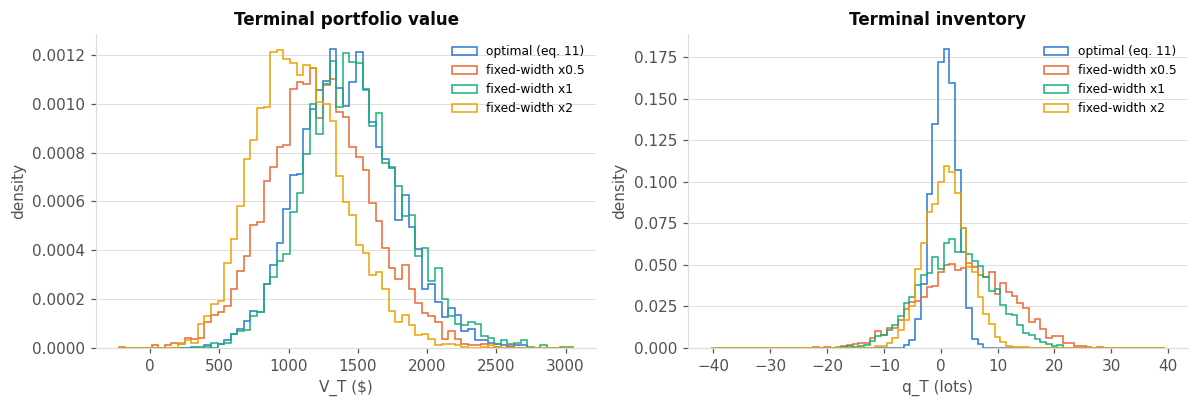

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(min(r.terminal_value.min() for r in runs.values()),
                   max(r.terminal_value.max() for r in runs.values()), 70)
for color, (name, r) in zip(SERIES, runs.items()):
    axes[0].hist(r.terminal_value, bins=bins, histtype='step', density=True, color=color, label=name)
    axes[1].hist(r.q[:, -1], bins=np.arange(-40, 41) - 0.5, histtype='step', density=True,
                 color=color, label=name)
axes[0].set_title('Terminal portfolio value'); axes[0].set_xlabel('V_T ($)'); axes[0].set_ylabel('density')
axes[1].set_title('Terminal inventory'); axes[1].set_xlabel('q_T (lots)'); axes[1].set_ylabel('density')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()



**Comment:** At plain profit ($V_T$):
the fixed-width quoter at $1\times$ the model's own $1/\kappa^i \text{ for } i=b,a$, **makes more money on average**
than the optimal rule (\$1,472 vs \$1,431). It never widens for inventory, so it never turns away a
trade, it just keeps collecting spread non-stop, while the optimal rule
deliberately makes its own quote less attractive whenever it is carrying a position (§5), which
sometimes means missing a fill it would have been happy to take.

The left-hand histogram shows exactly this: the green "$\times1$" curve for terminal portfolio value
sits slightly shifted to the right of the blue "optimal" curve. On raw dollars, the fixed width wins.

But the model
was built to maximise eq. 2, profit *minus* a fee for carrying inventory the whole time. So on the right histogram, the $\times1$ quoter earned \$41 more raw profit than optimal, but paid \$289 in fees for it, against
optimal's \$47 — so optimal finishes **\$202 ahead** once the actual cost of the risk taken is
counted in Objective instead of plain $V_T$.



## 7. Realized vol vs Maker's vol edge



Earlier sections assumed the maker's opinion about
volatility is *correct*. This section lets belief and reality disagree. `realised_sigma` splits one
number into two: what the maker believes — which sets every quote they post — and what the
spot actually does, which drives the simulation. Before this they were forced to match.

**The test:** two trading windows (half a day vs ten days) crossed with two levels of beliefs (the
maker thinks vol will be 5 points above the implied vol vs 20 points above it) — four
combinations in total.

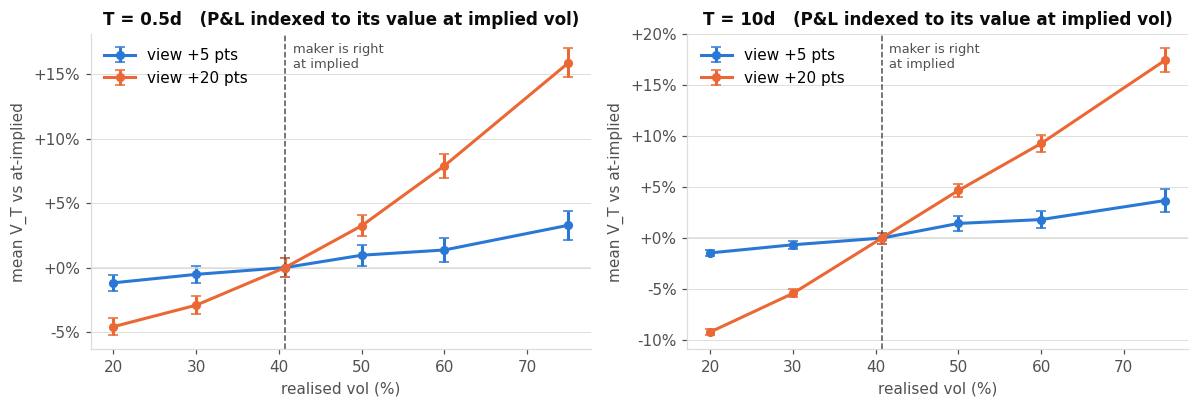

,case,mean V_T at implied,mean OBJECTIVE at implied,V_T range (20%-75% vol),range as % of P&L,range as % of OBJECTIVE,mean |q| (lots)
0,"0.5d, view +5 pts","1,423.129","1,376.030",63.625,4.5%,4.6%,1.584
1,"0.5d, view +20 pts","1,413.977","1,320.190",289.559,20.5%,21.9%,2.374
2,"10d, view +5 pts","28,193.492","27,267.695","1,449.183",5.1%,5.3%,1.805
3,"10d, view +20 pts","28,323.202","25,776.239","7,555.078",26.7%,29.3%,3.186


In [ ]:
realised = np.array([0.20, 0.30, IV, 0.50, 0.60, 0.75])

# Mean V_T as a function of the vol the spot ACTUALLY realises, holding the
# maker's belief -- and therefore every quote they post -- fixed at IV + gap.
def sweep(horizon_days, believed_gap, n_paths=3000, steps=600, seed=6):
    p = replace(PARAMS, sigma=IV + believed_gap)
    rows = []
    for rs in realised:
        r = simulate(surface, K, tau, horizon_days / 252, p, S0=S0, n_steps=steps,
                     n_paths=n_paths, seed=seed, realised_sigma=float(rs))
        rows.append({'realised vol': rs, 'mean V_T': r.terminal_value.mean(),
                     '95% CI': 1.96 * r.terminal_value.std() / np.sqrt(n_paths),
                     'mean |q|': np.abs(r.q).mean(),
                     'mean OBJECTIVE': objective(r, p).mean()})
    return pd.DataFrame(rows)

cases = {
    '0.5d, view +5 pts':  sweep(0.5, 0.05),
    '0.5d, view +20 pts': sweep(0.5, 0.20),
    '10d, view +5 pts':   sweep(10.0, 0.05),
    '10d, view +20 pts':  sweep(10.0, 0.20),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, horizon in zip(axes, ('0.5d', '10d')):
    subset = {k: v for k, v in cases.items() if k.startswith(horizon + ',')}
    for color, (label, df) in zip(SERIES, subset.items()):
        base = float(df.loc[np.isclose(df['realised vol'], IV), 'mean V_T'].iloc[0])
        ax.errorbar(df['realised vol'] * 100, df['mean V_T'] / base - 1,
                    yerr=df['95% CI'] / base, color=color, marker='o', ms=5,
                    capsize=3, label=label.split(', ')[1])
    ax.axvline(IV * 100, color=MUTED, lw=1, ls='--')
    ax.axhline(0, color=GRID, lw=1)
    ax.annotate('maker is right\nat implied', xy=(IV * 100, ax.get_ylim()[1]),
                xytext=(5, -22), textcoords='offset points', color=MUTED, fontsize=8.5)
    ax.set_title(f'T = {horizon}   (P&L indexed to its value at implied vol)')
    ax.set_xlabel('realised vol (%)'); ax.set_ylabel('mean V_T vs at-implied')
    ax.yaxis.set_major_formatter(lambda v, _: f'{v:+.0%}')
    ax.legend(); ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

sensitivity = pd.DataFrame([
    {'case': label,
     'mean V_T at implied': (base := float(df.loc[np.isclose(df['realised vol'], IV), 'mean V_T'].iloc[0])),
     'mean OBJECTIVE at implied': (base_obj := float(df.loc[np.isclose(df['realised vol'], IV), 'mean OBJECTIVE'].iloc[0])),
     'V_T range (20%-75% vol)': (rng := df['mean V_T'].max() - df['mean V_T'].min()),
     'range as % of P&L': f"{rng / base:.1%}",
     'range as % of OBJECTIVE': f"{rng / base_obj:.1%}",
     'mean |q| (lots)': df['mean |q|'].mean()}
    for label, df in cases.items()
])
display(sensitivity)


The x-axis is what happened (realized vol). The y-axis is profit,
*indexed*: shown as a \% difference from whatever the maker would have made had reality landed
exactly on the option market's own number, $\sigma_{\text{imp}}$ (the dashed line) — **not** the
maker's own bet, which by construction always sits 5 or 20 points above that line. 

**Comment:** 

- Compare colours *within* a panel first: **the strong view (+20 points) is a far steeper line than the mild view (+5 points)**.  Half a day, +5-point view: P&L moves **4.5%** across realised vol from 20% to 75%. The maker
  could be wrong by twenty vol points in either direction and barely notice. Ten days, same view: only **5.1%**. Ten times the horizon buys almost no extra vol exposure.
  
- Comparing the
*same* colour *across* the two panels (half a day vs ten days) — they are **nearly identical slopes**.
Twenty times the horizon barely changes how exposed the maker is to being wrong.


For the `mean |q|` column. Lengthening the horizon barely raise $|q|$,
because $\psi_2$ pushes back (see below) — the position never builds up. **Only higher belief raises $|q|$**, by skewing the quote hard enough to
keep winning the side of the trade the maker wants.

Note that **both cases at a given horizon earn the same P&L and Objective *at* implied vol (Columns 2,3)**


=> Absolute P&L scales roughly linearly with $T$ (more time = more spread captured), but the fraction of P&L attributable to the vol view stays roughly stable across horizons


---
**Why $\psi_2$ Caps Inventory: The Restoring-Force Mechanism in the model**

The complete causal chain is:

$$\psi_2 \;\longrightarrow\; \text{spreads} \;\longrightarrow\; \text{fill rates} \;\longrightarrow\; \text{inventory behavior}$$


---

Step 1: $\psi_2$ Shapes the Optimal Spreads

The optimal bid and ask spreads are defined by:

$$\delta^{\text{b},*} = \frac{1}{\kappa^{\text{b}}} - \psi_1 - (2q+1)\psi_2, \qquad \delta^{\text{a},*} = \frac{1}{\kappa^{\text{a}}} + \psi_1 + (2q-1)\psi_2$$

Because $\psi_2 < 0$ always, we write $\psi_2 = -\vert{}\psi_2\vert{}$ to highlight the direction of the shift:

$$\delta^{\text{b},*} = \frac{1}{\kappa^{\text{b}}} - \psi_1 + (2q+1)\vert{}\psi_2\vert{}, \qquad \delta^{\text{a},*} = \frac{1}{\kappa^{\text{a}}} + \psi_1 - (2q-1)\vert{}\psi_2\vert{}$$

Through the term $(2q \pm 1)\psi_2$, $\psi_2$ scales the impact of inventory $q$ on pricing. When $q$ is large and positive, the bid spread gets wider, the ask spread gets tighter. $\psi_2$ is just a number multiplying $q$ inside the spread — it doesn't know what inventory is, it just tilts the prices.

---

Step 2: Spreads Govern Fill Intensities

According to the intensity function:
$\lambda^i = \lambda_0^i e^{-\kappa^i\delta^{i,*}}$

A wider bid means fewer people sell to us (lower buy rate). A tighter ask means more people buy from us (higher sell rate). **The fill rates are set by the market's response to our quoted prices, not by any internal constraint on our inventory.** Substituting the spreads yields:

$$\lambda^{\text{b}}(q) = \lambda_0^{\text{b}}\,e^{-1}\,e^{\kappa^{\text{b}}\psi_1}\,e^{-\kappa^{\text{b}}(2q+1)\vert{}\psi_2\vert{}}
\qquad \lambda^{\text{a}}(q) = \lambda_0^{\text{a}}\,e^{-1}\,e^{-\kappa^{\text{a}}\psi_1}\,e^{+\kappa^{\text{a}}(2q-1)\vert{}\psi_2\vert{}}$$

The first three terms in each equation are constants independent of $q$. The entire inventory dependence resides in the final exponential factor.  

---

Step 3: Fill Rates Control Inventory Drift

**The fill rates determine how inventory moves.** More sells than buys arriving $\rightarrow q$ drifts down. More buys than sells $\rightarrow q$ drifts up. The inventory process is just the running count of fills that actually happen.

**When $q$ is large and positive (long position):**

* **Bid Spread:** $(2q+1)\vert{}\psi_2\vert{}$ is large and positive $\implies \delta^{\text{b},*}$ widens $\implies \lambda^{\text{b}}$ drops exponentially. We offer to buy far below fair value, so buy fills stop.
* **Ask Spread:** $(2q-1)\vert{}\psi_2\vert{}$ is large and positive $\implies \delta^{\text{a},*}$ shrinks $\implies \lambda^{\text{a}}$ rises exponentially. We offer to sell at or below fair value, increasing sell fills.

This asymmetry forces $q$ to drift back down toward zero. A symmetric mechanism applies when $q$ is large and negative (the ask widens and the bid tightens, pushing $q$ back up).

Each unit increase in $q$ multiplies the buy rate by a factor less than 1 and the sell rate by a factor greater than 1:

$$\frac{\lambda^{\text{b}}(q+1)}{\lambda^{\text{b}}(q)} = e^{-2\kappa^{\text{b}}\vert{}\psi_2\vert{}} < 1 \qquad \text{(buy rate drops)},\qquad \qquad \frac{\lambda^{\text{a}}(q+1)}{\lambda^{\text{a}}(q)} = e^{+2\kappa^{\text{a}}\vert{}\psi_2\vert{}} > 1 \qquad \text{(sell rate rises)}$$

---

Why Lengthening $T$ Does Not Increase Mean $\vert{}q\vert{}$

In the equilibrium regime ($T - t \gg 1/\eta$):
$\vert{}\psi_2(t)\vert{} \approx \sqrt{\varUpsilon\beta} = \sqrt{\frac{\beta}{2e^{-1}(\lambda_0^{\text{a}}\kappa^{\text{a}} + \lambda_0^{\text{b}}\kappa^{\text{b}})}}$

Every variable on the right-hand side ($\beta, \lambda_0^{\text{a}}, \kappa^{\text{a}}, \lambda_0^{\text{b}}, \kappa^{\text{b}}$) is a fixed parameter. Therefore, 
Mean $|q|$ doesn't grow with 
$T$ because the fill rates that determine inventory movement depend only on the current 
$q$ and on $\psi_2(t)$ — neither of which depends on $T$.

So the restoring force has the same strength
whether $T = 0.5$ or $T = 10$ days. More time just means more bouncing within the same
range, not a wider range.